In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [8]:
df = pd.read_csv("data.csv")
# df = pd.read_csv("../dataset/boston.csv")

In [9]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [5]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [6]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

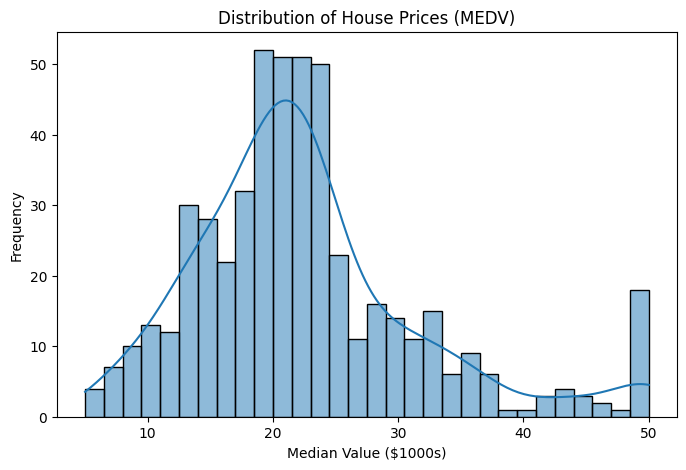

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['MEDV'], bins=30, kde=True)
plt.title("Distribution of House Prices (MEDV)")
plt.xlabel("Median Value ($1000s)")
plt.ylabel("Frequency")
plt.show()

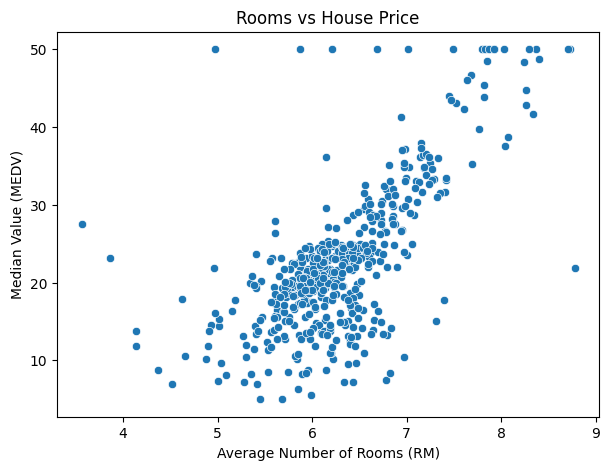

In [8]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='RM', y='MEDV', data=df)
plt.title("Rooms vs House Price")
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median Value (MEDV)")
plt.show()

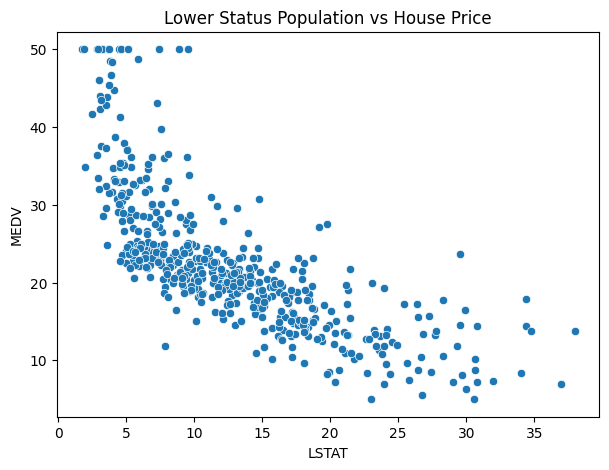

In [9]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='LSTAT', y='MEDV', data=df)
plt.title("Lower Status Population vs House Price")
plt.xlabel("LSTAT")
plt.ylabel("MEDV")
plt.show()

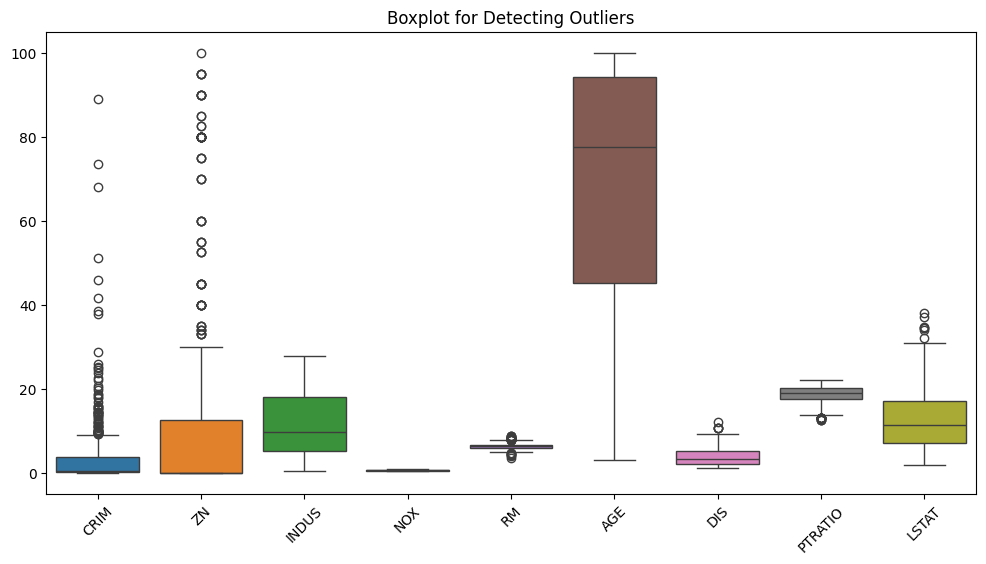

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['CRIM','ZN','INDUS','NOX','RM','AGE','DIS','PTRATIO','LSTAT']])
plt.xticks(rotation=45)
plt.title("Boxplot for Detecting Outliers")
plt.show()


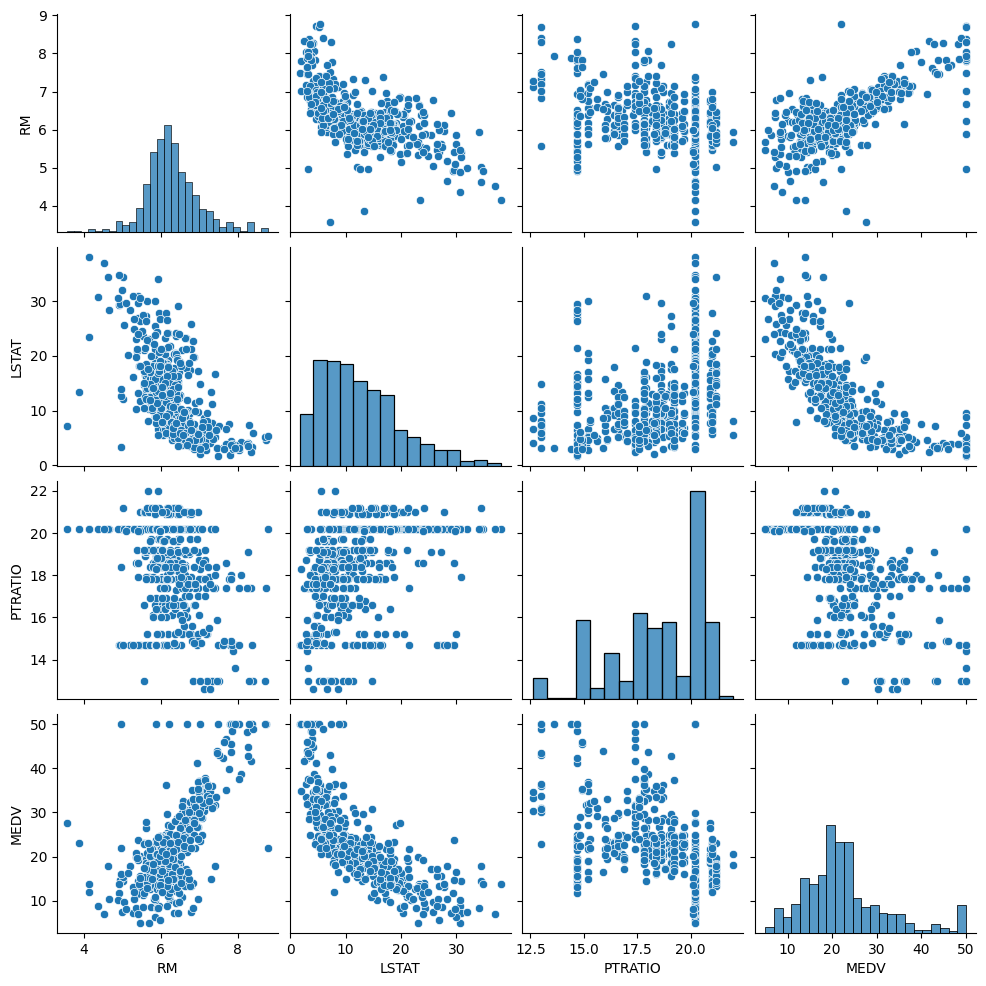

In [11]:
sns.pairplot(df[['RM','LSTAT','PTRATIO','MEDV']])
plt.show()


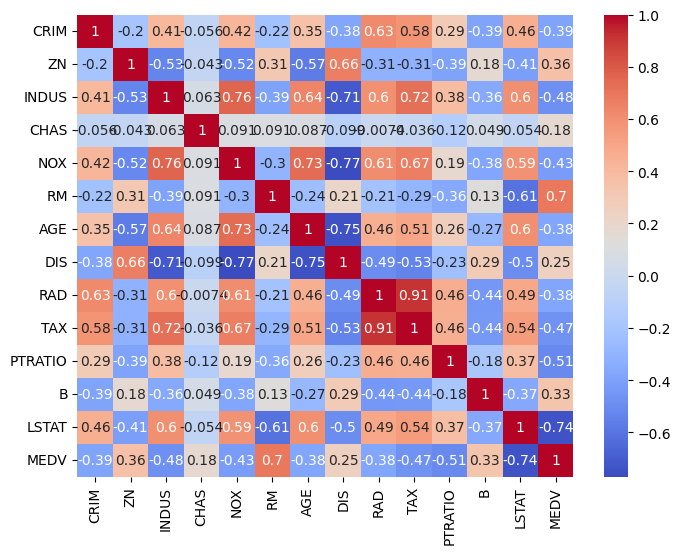

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [13]:
X = df.drop(columns=["MEDV","CRIM","B","RM","CHAS"], axis=1)
y = df["MEDV"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
le = LinearRegression() 

In [17]:
le

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
le.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
y_pred = le.predict(X_test)

In [20]:
y_pred

array([30.90645959, 34.18658144, 11.25065202, 25.88460932, 16.2051531 ,
       22.89327862, 17.32721897,  9.30339629, 22.15382765, 20.71536837,
       22.62760092, 19.07596039,  0.96343597, 20.47814482, 21.82416748,
       22.03012975, 20.87255205,  6.42748779, 38.19169685, 15.80871216,
       28.34172877, 30.90893608, 10.63519765, 22.89946034, 18.36478029,
       17.85741997, 23.69597488, 14.80929219, 19.8731576 , 20.0399529 ,
       26.22717974, 25.49675714, 22.17757829, 21.78442505, 14.91218441,
       20.42735188, 30.04886726, 21.93503459, 20.71740414, 24.10436451,
       14.18362138, 32.99809685, 40.02923587, 18.5501337 , 28.41871771,
       17.44253747, 15.05587121, 24.82092941, 18.25192138, 32.13929833,
       22.90649752, 34.74492293, 14.34319445, 24.73877881, 39.20200162,
       20.7503394 , 17.08597228, 33.35938171, 25.09186789, 13.32466823,
       20.45593694, 28.86159191, 32.62494164, 19.3510601 , 20.01266239,
       15.05368718, 17.94035426, 26.93591435, 32.00466372, 14.25

In [21]:
le.coef_

array([ 1.05641635, -0.18532387, -2.20137646,  0.68456258, -3.51180274,
        2.72054259, -2.66548158, -2.57124223, -6.12096521])

In [22]:
le.intercept_

np.float64(22.796534653465343)

In [23]:
print("mean Squared error : ",mean_squared_error(y_test,y_pred))
print("R2 score : ",r2_score(y_test,y_pred))

mean Squared error :  20.665940810412494
R2 score :  0.7181934448242984


In [24]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [25]:
new_data = pd.DataFrame([{
    "ZN": 0.0,
    "INDUS": 11.93,
    "NOX": 0.573,
    "AGE": 70.0,
    "DIS": 2.5,
    "RAD": 1,
    "TAX": 273,
    "PTRATIO": 21.0,
    "LSTAT": 6.0
}])
scaler = StandardScaler()
new_scaled = scaler.fit_transform(new_data)
prediction = le.predict(new_scaled)

print("Original Price:", df["MEDV"][0])
print("Predicted Price:", prediction[0])
print("accuracy : ",(prediction[0]/df["MEDV"][0])*100,"%")

Original Price: 24.0
Predicted Price: 22.796534653465343
accuracy :  94.9855610561056 %


In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

m = model.coef_[0]      # slope
b = model.intercept_    # intercept

print("Slope (m):", m)
print("Intercept (b):", b)


Slope (m): 0.0620564349324245
Intercept (b): 73.00542093804346
